# EMPIRICAL EVALUATION OF THE RAG SYSTEM (SEC 10-K ABLATION STUDY)
**Course:** Natural Language Processing (NLP)  
**Presenter:** [Student Name]  
**Objective:** Empirical analysis of the Information Retrieval quality of 5 system configurations on a standardized 80-question benchmark.

---
## 1. THEORETICAL FOUNDATIONS & MATHEMATICAL FORMULAS

To assess the quality of the RAG system, we evaluate the performance of the **Retrieval** component at threshold $K = 5$. Below are the mathematical formulas used:

### 1.1 Recall@K (Coverage)
The proportion of text chunks containing the correct answer (Ground Truth) that are successfully retrieved by the system in the Top-K:

$$\text{Recall@K} = \frac{|\mathcal{R}_K \cap \mathcal{G}|}{|\mathcal{G}|}$$

Where:
* $\mathcal{R}_K$: The set of Top-K documents returned by the system.
* $\mathcal{G}$: The set of ground truth correct documents.

### 1.2 MRR@K (Mean Reciprocal Rank)
Evaluates the rank position of the first relevant document found. Heavily penalizes if the correct document lies at lower ranks:

$$\text{MRR@K} = \frac{1}{|Q|} \sum_{q=1}^{|Q|} \text{RR}_q(K)$$

$$\text{RR}_q(K) = \begin{cases} \frac{1}{r_q} & \text{if } 1 \le r_q \le K \\ 0 & \text{otherwise} \end{cases}$$
*(where $r_q$ is the rank of the first correct document found)*

### 1.3 NDCG@K (Normalized Discounted Cumulative Gain)
Evaluates the cumulative relevance of all Top-K candidates, applying a logarithmic position discount according to their ranking:

$$\text{DCG@K} = \sum_{i=1}^{K} \frac{rel_i}{\log_2(i + 1)}$$
$$\text{IDCG@K} = \sum_{i=1}^{\min(K, |\mathcal{G}|)} \frac{1}{\log_2(i + 1)}$$
$$\text{NDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}$$

*(in this empirical study, the relevance level $rel_i \in \{0, 1\}$)*

### 1.4 Reciprocal Rank Fusion (RRF)
An algorithm to merge rankings from Lexical (BM25) and Semantic (Dense HNSW) search paths without needing to normalize original scores:

$$\text{RRF\_Score}(d \in \mathcal{D}) = \frac{1}{k + r_{\text{BM25}}(d)} + \frac{1}{k + r_{\text{Dense}}(d)}$$
*(with smoothing constant $k = 60$)*

In [1]:
# 2. IMPORT LIBRARIES & VISUALIZATION CONFIGURATION
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

In [2]:
# 3. LOAD EXPERIMENTAL RESULTS DATA
results_file = Path("../../eval/results/summary_report.json")
with open(results_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# Convert data to Pandas DataFrame for easy calculation
overall_metrics = []
category_metrics = []

for config_id, content in data.items():
    desc = content["desc"]
    overall = content["overall"]
    overall_metrics.append({
        "Config": config_id,
        "Description": desc,
        "Recall@5": overall["recall@5"],
        "MRR@5": overall["mrr"],
        "NDCG@5": overall["ndcg@5"],
        "Latency (ms)": overall["latency_ms"]
    })
    
    for cat, metrics in content["by_category"].items():
        category_metrics.append({
            "Config": desc,
            "Category": cat.capitalize().replace("_", " "),
            "Recall@5": metrics["recall@5"],
            "MRR@5": metrics["mrr"],
            "NDCG@5": metrics["ndcg@5"],
            "Latency (ms)": metrics["latency_ms"]
        })

df_overall = pd.DataFrame(overall_metrics)
df_category = pd.DataFrame(category_metrics)

print("=== OVERALL METRICS TABLE ===")
display(df_overall)

=== OVERALL METRICS TABLE ===


,Config,Description,Recall@5,MRR@5,NDCG@5,Latency (ms)
0,Config_A,TF-IDF Baseline,0.2875,0.2250,0.2258,6.73
1,Config_B,BM25 Baseline,0.4562,0.3602,0.3512,24.70
2,Config_C,Dense HNSW Search,0.5000,0.4158,0.3996,46.14
3,Config_D,Hybrid (BM25 + Dense),0.5750,0.4227,0.4467,76.29
4,Config_E,Enhanced RAG Pipeline,0.7719,0.6056,0.6184,2002.80


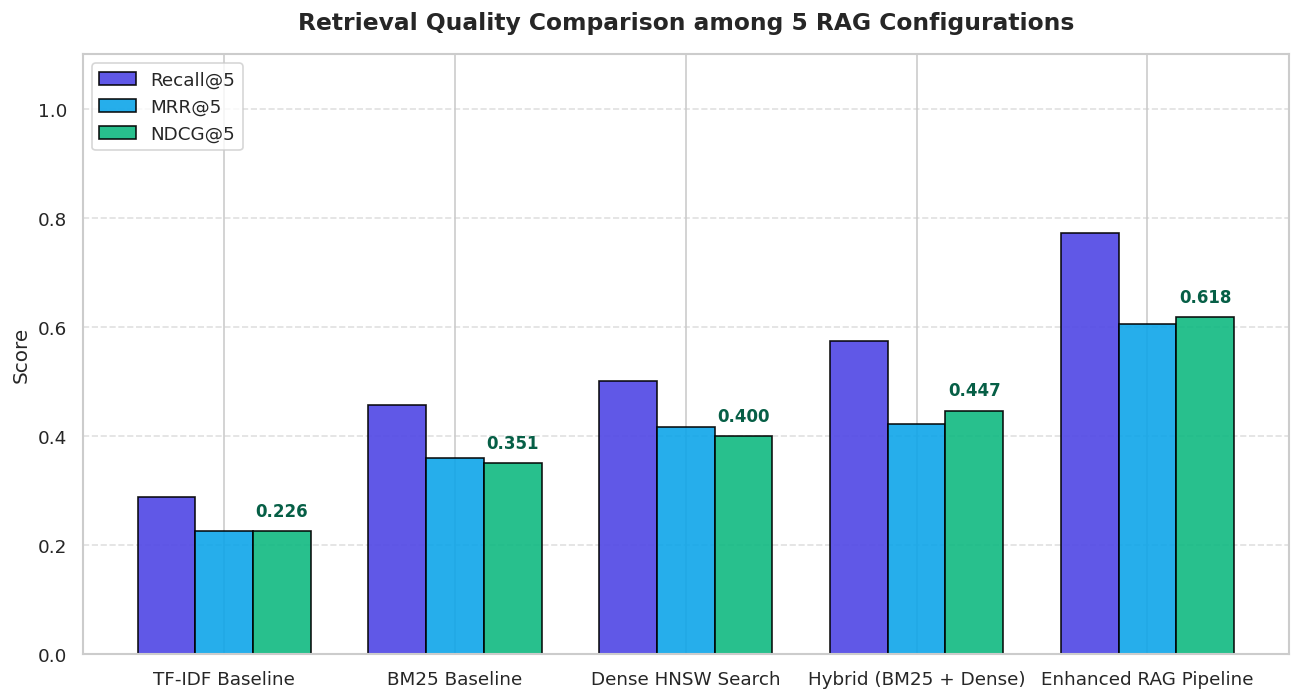

In [3]:
# 4. PLOT 1: RETRIEVAL QUALITY COMPARISON (Recall vs MRR vs NDCG)
plt.figure(figsize=(11, 6))
x = np.arange(len(df_overall))
width = 0.25

plt.bar(x - width, df_overall["Recall@5"], width, label="Recall@5", color="#4f46e5", edgecolor="black", alpha=0.9)
plt.bar(x, df_overall["MRR@5"], width, label="MRR@5", color="#0ea5e9", edgecolor="black", alpha=0.9)
plt.bar(x + width, df_overall["NDCG@5"], width, label="NDCG@5", color="#10b981", edgecolor="black", alpha=0.9)

plt.title("Retrieval Quality Comparison among 5 RAG Configurations", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Score", fontsize=12)
plt.xticks(x, df_overall["Description"], fontsize=11)
plt.ylim(0, 1.1)
plt.legend(fontsize=11, loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Annotate NDCG values on bars
for i, val in enumerate(df_overall["NDCG@5"]):
    plt.text(i + width, val + 0.02, f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold", color="#065f46")

plt.tight_layout()
plt.savefig("../../eval/figures/metrics_ablation_comparison.png", dpi=150)
plt.show()

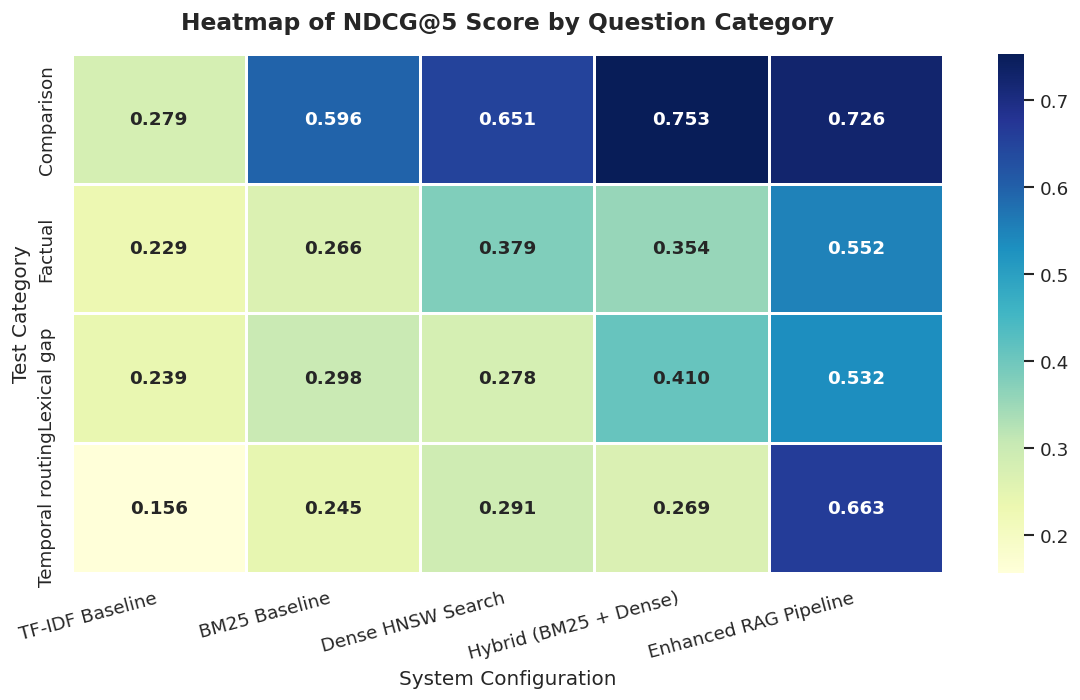

In [4]:
# 5. PLOT 2: HEATMAP OF NDCG@5 BY QUESTION CATEGORY
pivot_ndcg = df_category.pivot(index="Category", columns="Config", values="NDCG@5")
# Sort columns by increasing order of config complexity
cols_order = ["TF-IDF Baseline", "BM25 Baseline", "Dense HNSW Search", "Hybrid (BM25 + Dense)", "Enhanced RAG Pipeline"]
pivot_ndcg = pivot_ndcg[cols_order]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_ndcg, annot=True, fmt=".3f", cmap="YlGnBu", cbar=True, linewidths=0.8, linecolor="white",
            annot_kws={"size": 11, "weight": "bold"})

plt.title("Heatmap of NDCG@5 Score by Question Category", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("System Configuration", fontsize=12)
plt.ylabel("Test Category", fontsize=12)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../../eval/figures/heatmap_category_ndcg.png", dpi=150)
plt.show()

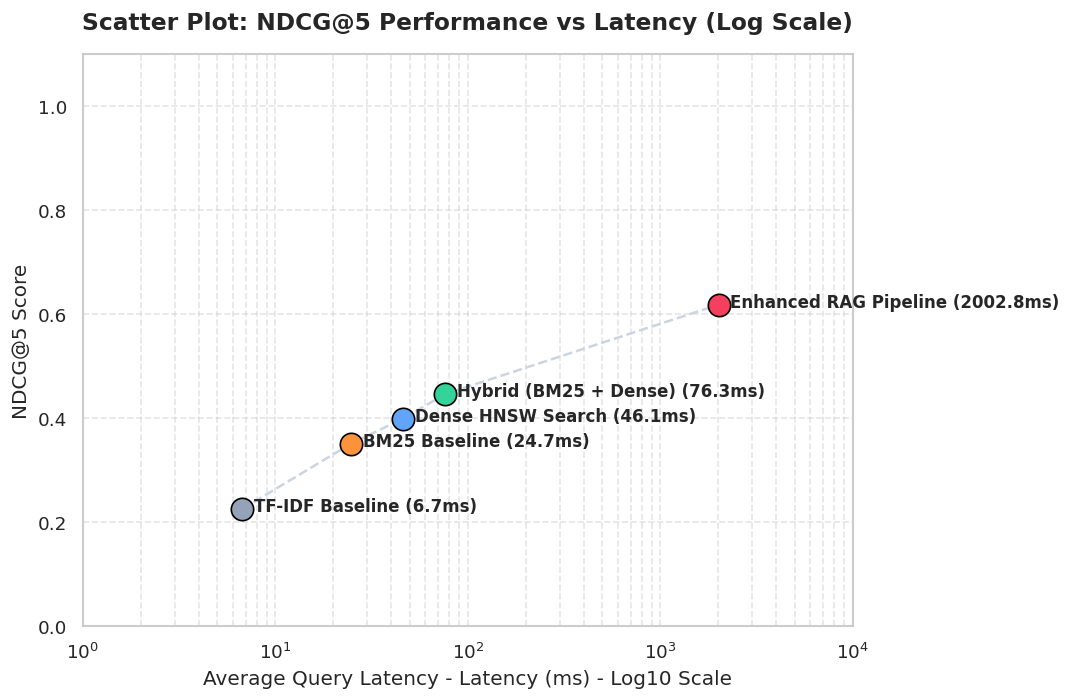

In [5]:
# 6. PLOT 3: LATENCY VS QUALITY TRADE-OFF (Latency vs NDCG@5 Scatter Plot)
plt.figure(figsize=(9, 6))
colors = ["#94a3b8", "#fb923c", "#60a5fa", "#34d399", "#f43f5e"]

for idx, row in df_overall.iterrows():
    plt.scatter(row["Latency (ms)"], row["NDCG@5"], s=180, color=colors[idx], label=row["Description"], 
                edgecolor="black", zorder=3)
    plt.text(row["Latency (ms)"] * 1.15, row["NDCG@5"] - 0.005, f"{row['Description']} ({row['Latency (ms)']:.1f}ms)",
             fontsize=10, fontweight="bold")

# Plot Pareto Frontier trend line
plt.plot(df_overall["Latency (ms)"], df_overall["NDCG@5"], linestyle="--", color="#cbd5e1", zorder=1)

plt.xscale("log") # Use log scale for x-axis due to large latency difference of Config E
plt.title("Scatter Plot: NDCG@5 Performance vs Latency (Log Scale)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Average Query Latency - Latency (ms) - Log10 Scale", fontsize=12)
plt.ylabel("NDCG@5 Score", fontsize=12)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.xlim(1, 10000)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig("../../eval/figures/latency_vs_ndcg_tradeoff.png", dpi=150)
plt.show()

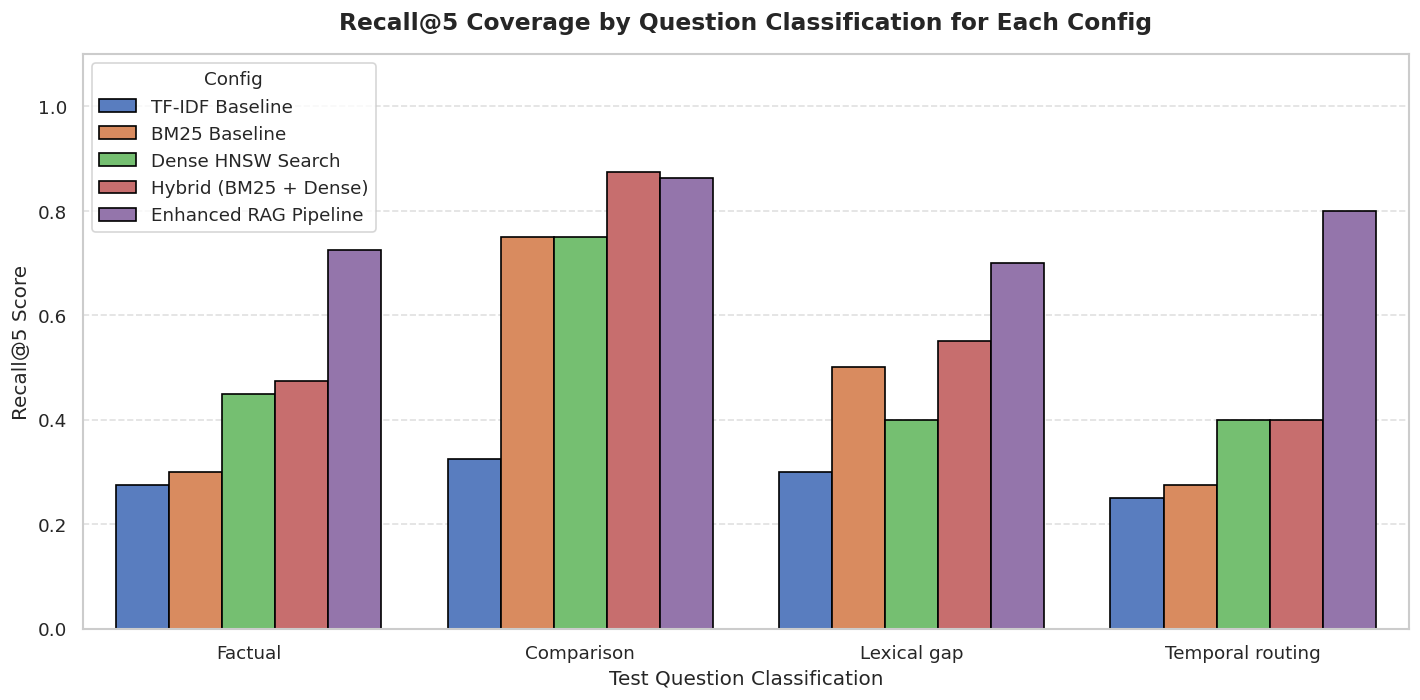

In [6]:
# 7. PLOT 4: DETAILED RECALL@5 ANALYSIS BY PROBLEM ASPECT
plt.figure(figsize=(12, 6))
sns.barplot(data=df_category, x="Category", y="Recall@5", hue="Config", palette="muted", edgecolor="black")

plt.title("Recall@5 Coverage by Question Classification for Each Config", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Test Question Classification", fontsize=12)
plt.ylabel("Recall@5 Score", fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title="Config", title_fontsize=11, loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("../../eval/figures/recall_by_category_breakdown.png", dpi=150)
plt.show()

---
## 8. NLP PROJECT DEFENSE Q&A (PREPARATION FOR THE PROFESSOR)

### 💬 Question 1: Why does BM25 outperform TF-IDF in this task?
* **Answer:** BM25 adds two core enhancements over traditional TF-IDF:
  1. **Term Frequency Saturation:** Limits the contribution of a keyword appearing too many times in a single text chunk (tuned by parameter $k_1$). This prevents a chunk that repeatedly repeats a single keyword from dominating chunks that have keyword occurrences distributed more evenly.
  2. **Document Length Normalization:** Penalizes overly long documents using parameter $b$. This prevents the system from being biased toward selecting longer chunks simply because they happen to contain more words.

### 💬 Question 2: Why does the HNSW Dense Vector model (C) handle the Lexical Gap better than BM25?
* **Answer:** BM25 relies on exact character matching (Exact Keyword Matching). When the question uses financial abbreviations (e.g., `capex` or `R&D spend`) while the original 10-K report writes them out in full (`capital expenditures` or `research and development expense`), BM25 will score 0.
* Dense Vector uses the `bge-small-en-v1.5` language model to map both the query and text chunks into a 384-dimensional semantic vector space. In this space, synonyms and abbreviations are mapped very close to each other, allowing HNSW to traverse the graph and retrieve the correct ground-truth chunk even if there is zero keyword overlap.

### 💬 Question 3: Analyze the latency spike in Config E. What is the practical solution?
* **Answer:** The latency spike in Config E (up to ~2.2 seconds on CPU) comes from the **Cross-Encoder Reranker** component.
  * Unlike a Bi-Encoder (which encodes Query and Document independently), a Cross-Encoder feeds the concatenated query and document text through the Transformer's Self-Attention layers to compute deep, joint relevance.
  * **Practical Solutions:**
    1. Accelerate hardware using GPUs that support Tensor FP8 cores (e.g., Blackwell architecture, which significantly speeds up FP8 computation by 2x).
    2. Pass only the Top-10 candidates from the RRF branch into the Reranker instead of the Top-20 to reduce the number of pairwise cross-computations.
    3. Apply Knowledge Distillation techniques to compress the Reranker into a smaller model size.